# Partie (3/3) : Données textuelles

## 1. Analyse de données

### importer le dataset

In [18]:
import pandas as pd

df_1= pd.read_csv("Data/all_data_with_identities.csv")
df_1.head()

,Unnamed: 0,id,comment_text,split,created_date,publication_id,parent_id,article_id,rating,funny,...,asian_latino_etc,disability_any,identity_any,num_identities,more_than_one_identity,na_gender,na_orientation,na_religion,na_race,na_disability
0,0,627762,OH yes - Were those evil Christian Missionarie...,test,2016-11-26 15:56:03.862109+00,13,627198.0,152737,approved,0,...,0,0,1,1.0,False,1,1,0,1,1
1,1,5892815,Why is this black racist crap still on the G&M...,val,2017-09-03 23:20:08.226613+00,54,NaN,373428,rejected,0,...,0,0,1,2.0,True,1,1,1,0,1
2,2,416437,even up here.......BLACKS!,train,2016-08-04 16:48:07.175252+00,21,NaN,143025,rejected,0,...,0,0,1,1.0,False,1,1,1,0,1
3,3,5137126,Blame men. There's always an excuse to blame ...,train,2017-04-15 19:00:45.032674+00,54,5136907.0,327125,rejected,0,...,0,0,1,2.0,True,0,1,1,1,1
4,4,855753,And the woman exposing herself saying grab thi...,val,2017-01-18 01:50:57.478867+00,13,849081.0,162008,rejected,0,...,0,0,1,1.0,False,0,1,1,1,1


In [19]:
df_1.columns

Index(['Unnamed: 0', 'id', 'comment_text', 'split', 'created_date',
       'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow',
       'sad', 'likes', 'disagree', 'toxicity', 'severe_toxicity', 'obscene',
       'sexual_explicit', 'identity_attack', 'insult', 'threat', 'male',
       'female', 'transgender', 'other_gender', 'heterosexual',
       'homosexual_gay_or_lesbian', 'bisexual', 'other_sexual_orientation',
       'christian', 'jewish', 'muslim', 'hindu', 'buddhist', 'atheist',
       'other_religion', 'black', 'white', 'asian', 'latino',
       'other_race_or_ethnicity', 'physical_disability',
       'intellectual_or_learning_disability', 'psychiatric_or_mental_illness',
       'other_disability', 'identity_annotator_count',
       'toxicity_annotator_count', 'LGBTQ', 'other_religions',
       'asian_latino_etc', 'disability_any', 'identity_any', 'num_identities',
       'more_than_one_identity', 'na_gender', 'na_orientation', 'na_religion',
       'na_race', 

In [20]:
df_text=df_1[["comment_text","toxicity","female","male","black","white","homosexual_gay_or_lesbian"]]

In [21]:
df_text.head()

,comment_text,toxicity,female,male,black,white,homosexual_gay_or_lesbian
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.00,0.0
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,1.0,0.75,0.0
2,even up here.......BLACKS!,0.688525,0.0,0.0,1.0,0.00,0.0
3,Blame men. There's always an excuse to blame ...,0.545455,1.0,1.0,0.0,0.00,0.0
4,And the woman exposing herself saying grab thi...,0.728571,1.0,0.0,0.0,0.00,0.0


In [22]:
print(df_text.head())

                                        comment_text  toxicity  female  male  \
0  OH yes - Were those evil Christian Missionarie...  0.800000     0.0   0.0   
1  Why is this black racist crap still on the G&M...  0.757143     0.0   0.0   
2                         even up here.......BLACKS!  0.688525     0.0   0.0   
3  Blame men.  There's always an excuse to blame ...  0.545455     1.0   1.0   
4  And the woman exposing herself saying grab thi...  0.728571     1.0   0.0   

   black  white  homosexual_gay_or_lesbian  
0    0.0   0.00                        0.0  
1    1.0   0.75                        0.0  
2    1.0   0.00                        0.0  
3    0.0   0.00                        0.0  
4    0.0   0.00                        0.0  


In [24]:
df_text.dtypes

comment_text                     str
toxicity                     float64
female                       float64
male                         float64
black                        float64
white                        float64
homosexual_gay_or_lesbian    float64
dtype: object

In [27]:
df_text.isnull().sum()

comment_text                 2
toxicity                     0
female                       0
male                         0
black                        0
white                        0
homosexual_gay_or_lesbian    0
dtype: int64

In [28]:
df_text.dropna(inplace=True)

### Indiquer les longueurs (min, max, moy, médiane, percentiles) des textes


In [ ]:
df_text['text_length'] = df_text['comment_text'].apply(len)

stats_longueurs = df_text['text_length'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99])
print("--- Statistiques des longueurs des textes ---")
print(stats_longueurs)

--- Statistiques des longueurs des textes ---
count    447998.000000
mean        351.744514
std         289.323425
min           1.000000
25%         121.000000
50%         257.000000
75%         512.000000
90%         872.000000
95%         984.000000
99%         999.000000
max        1891.000000
Name: text_length, dtype: float64


### Indiquer les distributions des longueurs de texte pour les classes toxiques/non toxiques. Commenter.


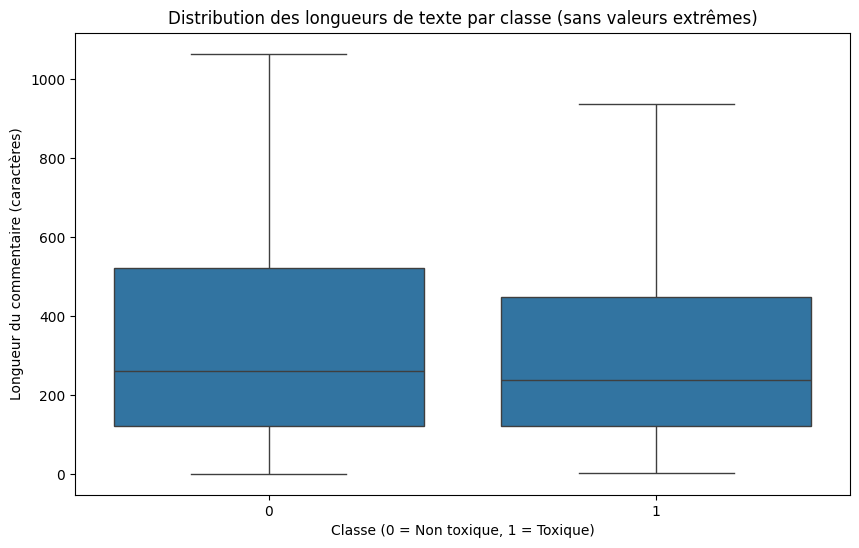

                mean  median   max
is_toxic                          
0         355.289773   260.0  1891
1         324.020947   238.0  1000


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

df_text['is_toxic'] = (df_text['toxicity'] >= 0.5).astype(int)

plt.figure(figsize=(10, 6))
sns.boxplot(x='is_toxic', y='text_length', data=df_text, showfliers=False)
plt.title("Distribution des longueurs de texte par classe (sans valeurs extrêmes)")
plt.xlabel("Classe (0 = Non toxique, 1 = Toxique)")
plt.ylabel("Longueur du commentaire (caractères)")
plt.show()

print(df_text.groupby('is_toxic')['text_length'].agg(['mean', 'median', 'max']))

les distributions sont assez proche mais on remarque tout de même que les commentaires toxiques ont une petite tendance à être plus courts que les commentaire non toxiques.

### Commenter l’équilibre du dataset.

Répartition des classes (%) :
 is_toxic
0    88.662003
1    11.337997
Name: proportion, dtype: float64


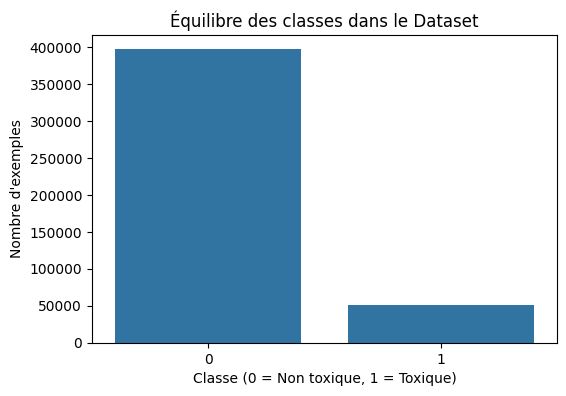

In [31]:
# Calcul de la répartition des classes en pourcentage
equilibre = df_text['is_toxic'].value_counts(normalize=True) * 100
print("Répartition des classes (%) :\n", equilibre)

plt.figure(figsize=(6, 4))
sns.countplot(x='is_toxic', data=df_text)
plt.title("Équilibre des classes dans le Dataset")
plt.xlabel("Classe (0 = Non toxique, 1 = Toxique)")
plt.ylabel("Nombre d'exemples")
plt.show()

On voit que l'on a beaucoup moins de commentaires toxiques que de commentaires non toxiques, ce qui peut poser problème pour l'entraînement d'un modèle de classification. 

### Commenter la distribution de la colonne toxicity (valeur continue)

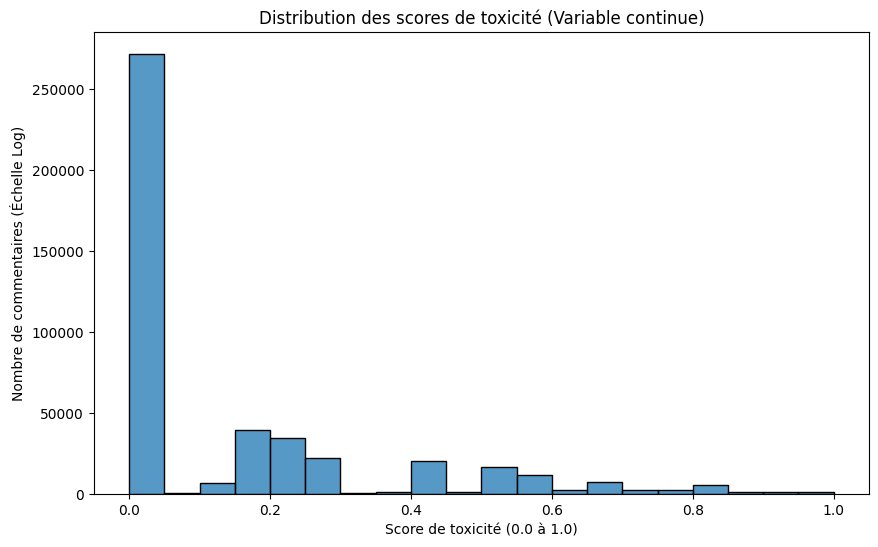

Proportion de textes avec une toxicité de pile 0.0 : 60.60%


In [32]:
plt.figure(figsize=(10, 6))
sns.histplot(df_text['toxicity'], bins=20, kde=False)
plt.title("Distribution des scores de toxicité (Variable continue)")
plt.xlabel("Score de toxicité (0.0 à 1.0)")
plt.ylabel("Nombre de commentaires (Échelle Log)") 
plt.show()

zero_prop = (df_text['toxicity'] == 0.0).mean() * 100
print(f"Proportion de textes avec une toxicité de pile 0.0 : {zero_prop:.2f}%")

In [34]:
around_02_prop = ((df_text['toxicity'] >= 0.15) & (df_text['toxicity'] <= 0.25)).mean() * 100
print(f"Proportion de textes avec une toxicité autour de 0.2 : {around_02_prop:.2f}%")

Proportion de textes avec une toxicité autour de 0.2 : 16.44%


On voit que beaucoup de commentaires ne sont pas du tout toxiques (60% des commentaires du dataset ont une toxicité de 0.0). On a un petit batch de commentaire autour de 0.2 de toxicité (16%). La suite des commentaire est répartie de manière décroissante jusqu'à 1.0, avec une petite pointe à 0.4 de toxicité. Donc on voit bien que la non toxicité prédomine suivie par la faible toxicité, et que les commentaires très toxiques sont assez rares.

## 2. Prétraitement et visualisation

In [3]:
from collections import Counter
from pathlib import Path
import pandas as pd
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from wordcloud import WordCloud
from tqdm.auto import tqdm

tqdm.pandas()

for corpus in ['punkt', 'punkt_tab', 'wordnet', 'stopwords', 'omw-1.4']:
    nltk.download(corpus, quiet=True)

dataset_path: Path = Path("../data/google_comments/all_data_with_identities.csv")

if not dataset_path.exists():
    raise FileNotFoundError("Dataset not found")

df = pd.read_csv(str(dataset_path))
df.dtypes

Unnamed: 0                               int64
id                                       int64
comment_text                               str
split                                      str
created_date                               str
publication_id                           int64
parent_id                              float64
article_id                               int64
rating                                     str
funny                                    int64
wow                                      int64
sad                                      int64
likes                                    int64
disagree                                 int64
toxicity                               float64
severe_toxicity                        float64
obscene                                float64
sexual_explicit                        float64
identity_attack                        float64
insult                                 float64
threat                                 float64
male         

In [4]:
df.dtypes

Unnamed: 0                               int64
id                                       int64
comment_text                               str
split                                      str
created_date                               str
publication_id                           int64
parent_id                              float64
article_id                               int64
rating                                     str
funny                                    int64
wow                                      int64
sad                                      int64
likes                                    int64
disagree                                 int64
toxicity                               float64
severe_toxicity                        float64
obscene                                float64
sexual_explicit                        float64
identity_attack                        float64
insult                                 float64
threat                                 float64
male         

In [5]:
len(df)

448000

In [6]:
# --- Toutes les colonnes du dataset ---
COL_ID                          = 'id'
COL_TEXT                        = 'comment_text'
COL_SPLIT                       = 'split'
COL_CREATED                     = 'created_date'
COL_PUBLICATION_ID              = 'publication_id'
COL_PARENT_ID                   = 'parent_id'
COL_ARTICLE_ID                  = 'article_id'
COL_RATING                      = 'rating'
COL_FUNNY                       = 'funny'
COL_WOW                         = 'wow'
COL_SAD                         = 'sad'
COL_LIKES                       = 'likes'
COL_DISAGREE                    = 'disagree'
COL_TOXICITY                    = 'toxicity'
COL_SEVERE_TOXICITY             = 'severe_toxicity'
COL_OBSCENE                     = 'obscene'
COL_SEXUAL_EXPLICIT             = 'sexual_explicit'
COL_IDENTITY_ATTACK             = 'identity_attack'
COL_INSULT                      = 'insult'
COL_THREAT                      = 'threat'
COL_MALE                        = 'male'
COL_FEMALE                      = 'female'
COL_TRANSGENDER                 = 'transgender'
COL_OTHER_GENDER                = 'other_gender'
COL_HETEROSEXUAL                = 'heterosexual'
COL_HOMOSEXUAL                  = 'homosexual_gay_or_lesbian'
COL_BISEXUAL                    = 'bisexual'
COL_OTHER_SEXUAL_ORIENTATION    = 'other_sexual_orientation'
COL_CHRISTIAN                   = 'christian'
COL_JEWISH                      = 'jewish'
COL_MUSLIM                      = 'muslim'
COL_HINDU                       = 'hindu'
COL_BUDDHIST                    = 'buddhist'
COL_ATHEIST                     = 'atheist'
COL_OTHER_RELIGION              = 'other_religion'
COL_BLACK                       = 'black'
COL_WHITE                       = 'white'
COL_ASIAN                       = 'asian'
COL_LATINO                      = 'latino'
COL_OTHER_RACE                  = 'other_race_or_ethnicity'
COL_PHYSICAL_DISABILITY         = 'physical_disability'
COL_INTELLECTUAL_DISABILITY     = 'intellectual_or_learning_disability'
COL_PSYCHIATRIC_DISABILITY      = 'psychiatric_or_mental_illness'
COL_OTHER_DISABILITY            = 'other_disability'
COL_IDENTITY_ANNOTATOR_COUNT    = 'identity_annotator_count'
COL_TOXICITY_ANNOTATOR_COUNT    = 'toxicity_annotator_count'
COL_LGBTQ                       = 'LGBTQ'
COL_OTHER_RELIGIONS             = 'other_religions'
COL_ASIAN_LATINO_ETC            = 'asian_latino_etc'
COL_DISABILITY_ANY              = 'disability_any'
COL_IDENTITY_ANY                = 'identity_any'
COL_NUM_IDENTITIES              = 'num_identities'
COL_MORE_THAN_ONE_IDENTITY      = 'more_than_one_identity'
COL_NA_GENDER                   = 'na_gender'
COL_NA_ORIENTATION              = 'na_orientation'
COL_NA_RELIGION                 = 'na_religion'
COL_NA_RACE                     = 'na_race'
COL_NA_DISABILITY               = 'na_disability'

# --- Colonnes utilisées dans l'analyse ---
ANALYSIS_COLS = [
    COL_TEXT,
    COL_TOXICITY,
    COL_FEMALE,
    COL_MALE,
    COL_BLACK,
    COL_WHITE,
    COL_HOMOSEXUAL,
]

DEMOGRAPHIC_COLS = [c for c in ANALYSIS_COLS if c not in (COL_TEXT, COL_TOXICITY)]


In [7]:
df = df[ANALYSIS_COLS]
df.head()


,comment_text,toxicity,female,male,black,white,homosexual_gay_or_lesbian
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.00,0.0
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,1.0,0.75,0.0
2,even up here.......BLACKS!,0.688525,0.0,0.0,1.0,0.00,0.0
3,Blame men. There's always an excuse to blame ...,0.545455,1.0,1.0,0.0,0.00,0.0
4,And the woman exposing herself saying grab thi...,0.728571,1.0,0.0,0.0,0.00,0.0


In [8]:
df.head(5)

,comment_text,toxicity,female,male,black,white,homosexual_gay_or_lesbian
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.00,0.0
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,1.0,0.75,0.0
2,even up here.......BLACKS!,0.688525,0.0,0.0,1.0,0.00,0.0
3,Blame men. There's always an excuse to blame ...,0.545455,1.0,1.0,0.0,0.00,0.0
4,And the woman exposing herself saying grab thi...,0.728571,1.0,0.0,0.0,0.00,0.0


### Nettoyage du dataset

In [9]:
import re

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)   # URLs
    text = re.sub(r'@\w+', '', text)                     # mentions @user
    text = re.sub(r'[^\w\s]', ' ', text)                 # ponctuation → espace
    text = re.sub(r'\s+', ' ', text).strip()             # espaces multiples
    return text

df[COL_TEXT] = df['comment_text'].map(clean_text)

# Binarisation de la colonne toxicity au seuil 0.5
df['label'] = (df['toxicity'] >= 0.5).astype(int)

print(f"Commentaires toxiques   : {df['label'].sum():,} ({df['label'].mean():.1%})")
print(f"Commentaires non-toxiques: {(df['label']==0).sum():,} ({(df['label']==0).mean():.1%})")


Commentaires toxiques   : 50,794 (11.3%)
Commentaires non-toxiques: 397,206 (88.7%)


### Tokenisation

In [10]:
COL_TOKENIZED = "tok"
COL_N_TOKENS  = "n_tokens"
COL_LEMMAS    = "lemmas"

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def tokenize_and_lemmatize(text: str) -> tuple[list[str], list[str]]:
    tokens = word_tokenize(text)
    lemmas = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t.isalpha() and t not in STOP_WORDS and len(t) > 1
    ]
    return tokens, lemmas

print("Tokenisation + lemmatisation...")
results = [tokenize_and_lemmatize(t) for t in tqdm(df[COL_TEXT], desc="NLTK tokenize/lemmatize")]

df[COL_TOKENIZED] = [r[0] for r in results]
df[COL_N_TOKENS]  = [len(r[0]) for r in results]
df[COL_LEMMAS]    = [r[1] for r in results]

print(f"Tokens moyen / commentaire : {df[COL_N_TOKENS].mean():.1f}")
print(f"Médiane                    : {df[COL_N_TOKENS].median():.0f}")
print(f"Max                        : {df[COL_N_TOKENS].max()}")


Tokenisation + lemmatisation...


NLTK tokenize/lemmatize:   0%|          | 0/448000 [00:00<?, ?it/s]

Tokens moyen / commentaire : 61.9
Médiane                    : 46
Max                        : 314


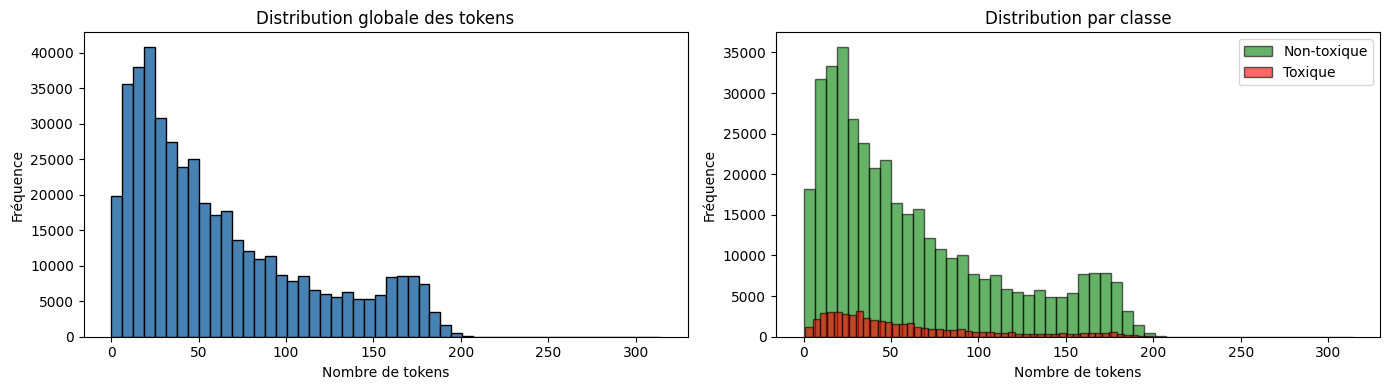

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df[COL_N_TOKENS], bins=50, color='steelblue', edgecolor='black')
axes[0].set(title='Distribution globale des tokens', xlabel='Nombre de tokens', ylabel='Fréquence')

for label, color, lbl in [(0, 'green', 'Non-toxique'), (1, 'red', 'Toxique')]:
    subset = df[df['label'] == label][COL_N_TOKENS]
    axes[1].hist(subset, bins=50, alpha=0.6, color=color, label=lbl, edgecolor='black')

axes[1].set(title='Distribution par classe', xlabel='Nombre de tokens', ylabel='Fréquence')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
df[[COL_TEXT, COL_TOKENIZED, COL_LEMMAS]].head(10)

,comment_text,tok,lemmas
0,oh yes were those evil christian missionaries ...,"[oh, yes, were, those, evil, christian, missio...","[oh, yes, evil, christian, missionary, many, s..."
1,why is this black racist crap still on the g m...,"[why, is, this, black, racist, crap, still, on...","[black, racist, crap, still, website, stopped,..."
2,even up here blacks,"[even, up, here, blacks]","[even, black]"
3,blame men there s always an excuse to blame me...,"[blame, men, there, s, always, an, excuse, to,...","[blame, men, always, excuse, blame, men, failu..."
4,and the woman exposing herself saying grab thi...,"[and, the, woman, exposing, herself, saying, g...","[woman, exposing, saying, grab, pussy, offer, ..."
5,you have no business making any comments on th...,"[you, have, no, business, making, any, comment...","[business, making, comment, site, craig, bigot..."
6,let s get the black folks and the white folks ...,"[let, s, get, the, black, folks, and, the, whi...","[let, get, black, folk, white, folk, others, t..."
7,i guess the issue is people not willing to put...,"[i, guess, the, issue, is, people, not, willin...","[guess, issue, people, willing, put, stupid, c..."
8,jackjohnson5 and they say trump supporters are...,"[jackjohnson5, and, they, say, trump, supporte...","[say, trump, supporter, uneducated, necessaril..."
9,trump could accidently push a button and canad...,"[trump, could, accidently, push, a, button, an...","[trump, could, accidently, push, button, canad..."


### Regroupement par nuage de mots

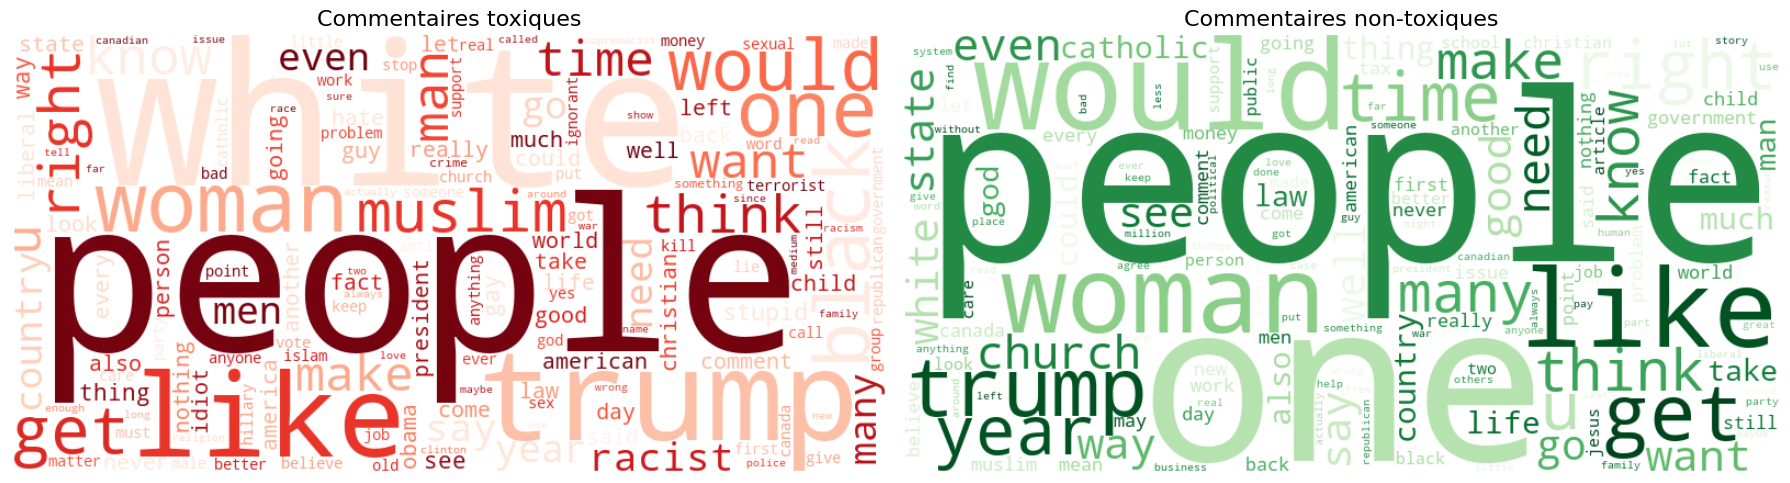

In [13]:
wc_config = dict(width=800, height=400, max_words=150, background_color='white')

def get_freq(df_subset: pd.DataFrame, col: str = COL_LEMMAS) -> Counter:
    all_tokens = [t for tokens in df_subset[col] for t in tokens]
    return Counter(all_tokens)

freq_toxic    = get_freq(df[df['label'] == 1])
freq_nontoxic = get_freq(df[df['label'] == 0])

# Nuages de mots séparés : toxique vs non-toxique
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc_t = WordCloud(colormap='Reds',   **wc_config).generate_from_frequencies(freq_toxic)
wc_n = WordCloud(colormap='Greens', **wc_config).generate_from_frequencies(freq_nontoxic)

axes[0].imshow(wc_t, interpolation='bilinear'); axes[0].axis('off')
axes[0].set_title('Commentaires toxiques', fontsize=16)
axes[1].imshow(wc_n, interpolation='bilinear'); axes[1].axis('off')
axes[1].set_title('Commentaires non-toxiques', fontsize=16)

plt.tight_layout()
plt.show()


Top 20 termes ambigus (score proche de 1 = présent également dans les deux classes) :
      term  freq_toxic  freq_nontoxic  ambiguity_score
     front    0.000242       0.000242         0.999743
     speak    0.000410       0.000410         0.999633
      come    0.001640       0.001640         0.999554
      died    0.000191       0.000191         0.999255
      fact    0.001805       0.001803         0.999133
        us    0.000113       0.000113         0.999035
acceptable    0.000113       0.000113         0.998807
   imagine    0.000262       0.000263         0.998571
      army    0.000115       0.000115         0.998307
      even    0.002925       0.002931         0.997870
    middle    0.000473       0.000472         0.997047
    unlike    0.000123       0.000123         0.996936
     whole    0.000510       0.000511         0.996589
     photo    0.000152       0.000152         0.996424
     thing    0.002440       0.002431         0.996040
  campaign    0.000401       0.000

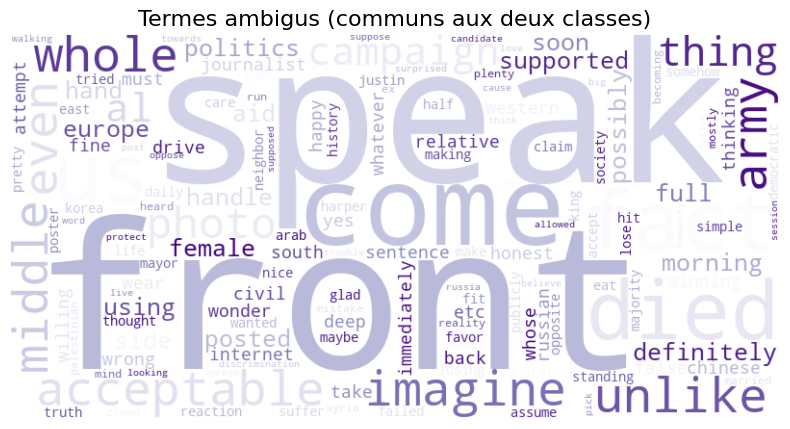

In [14]:
# Termes ambigus : communs aux deux classes avec un ratio de fréquence proche de 1
total_toxic    = sum(freq_toxic.values())
total_nontoxic = sum(freq_nontoxic.values())
common_terms   = set(freq_toxic) & set(freq_nontoxic)

ambiguity_records = []
for term in common_terms:
    tf_t  = freq_toxic[term]    / total_toxic
    tf_nt = freq_nontoxic[term] / total_nontoxic
    ratio = min(tf_t, tf_nt) / max(tf_t, tf_nt)
    ambiguity_records.append({
        'term': term,
        'freq_toxic': tf_t,
        'freq_nontoxic': tf_nt,
        'ambiguity_score': ratio,
    })

df_ambig = (pd.DataFrame(ambiguity_records)
              .sort_values('ambiguity_score', ascending=False)
              .query('freq_toxic > 1e-4 and freq_nontoxic > 1e-4')
              .reset_index(drop=True))

print("Top 20 termes ambigus (score proche de 1 = présent également dans les deux classes) :")
print(df_ambig.head(20).to_string(index=False))

wc_ambig = WordCloud(colormap='Purples', **wc_config).generate_from_frequencies(
    dict(zip(df_ambig['term'], df_ambig['ambiguity_score']))
)

plt.figure(figsize=(10, 5))
plt.imshow(wc_ambig, interpolation='bilinear')
plt.axis('off')
plt.title('Termes ambigus (communs aux deux classes)', fontsize=16)
plt.show()


### Analyse TF-IDF par classe

In [15]:
df['lemmas_str'] = [' '.join(lemmas) for lemmas in tqdm(df[COL_LEMMAS], desc="Jointure lemmes")]

N_FEATURES = 20_000

print("Calcul TF-IDF...")
vectorizer = TfidfVectorizer(max_features=N_FEATURES, min_df=5, sublinear_tf=True)
tfidf_matrix = vectorizer.fit_transform(tqdm(df['lemmas_str'], desc="TF-IDF vectorisation"))
vocab = vectorizer.get_feature_names_out()

idx_toxic    = df[df['label'] == 1].index
idx_nontoxic = df[df['label'] == 0].index

mean_tfidf_toxic    = tfidf_matrix[idx_toxic].mean(axis=0).A1
mean_tfidf_nontoxic = tfidf_matrix[idx_nontoxic].mean(axis=0).A1

df_tfidf = pd.DataFrame({
    'term':           vocab,
    'tfidf_toxic':    mean_tfidf_toxic,
    'tfidf_nontoxic': mean_tfidf_nontoxic,
})

TOP_N = 20

df_tfidf['ratio_toxic']    = df_tfidf['tfidf_toxic']    / (df_tfidf['tfidf_nontoxic'] + 1e-9)
df_tfidf['ratio_nontoxic'] = df_tfidf['tfidf_nontoxic'] / (df_tfidf['tfidf_toxic']    + 1e-9)

top_toxic    = df_tfidf.nlargest(TOP_N, 'tfidf_toxic')[['term','tfidf_toxic','tfidf_nontoxic','ratio_toxic']]
top_nontoxic = df_tfidf.nlargest(TOP_N, 'tfidf_nontoxic')[['term','tfidf_nontoxic','tfidf_toxic','ratio_nontoxic']]

print("=== Top termes TF-IDF élevé UNIQUEMENT dans la classe TOXIQUE ===")
print(top_toxic.to_string(index=False))
print()
print("=== Top termes TF-IDF élevé UNIQUEMENT dans la classe NON-TOXIQUE ===")
print(top_nontoxic.to_string(index=False))


Jointure lemmes:   0%|          | 0/448000 [00:00<?, ?it/s]

Calcul TF-IDF...


TF-IDF vectorisation:   0%|          | 0/448000 [00:00<?, ?it/s]

=== Top termes TF-IDF élevé UNIQUEMENT dans la classe TOXIQUE ===
  term  tfidf_toxic  tfidf_nontoxic  ratio_toxic
 white     0.025826        0.007762     3.327390
 trump     0.020788        0.011909     1.745577
people     0.018941        0.014647     1.293175
 black     0.018922        0.004547     4.161054
 woman     0.016645        0.012940     1.286308
  like     0.016478        0.013440     1.226036
muslim     0.015369        0.005597     2.745968
stupid     0.014454        0.000265    54.442163
racist     0.012611        0.002398     5.258902
   one     0.012567        0.014270     0.880628
 would     0.012372        0.014384     0.860168
   get     0.012320        0.011230     1.096992
   man     0.011961        0.008049     1.486040
 right     0.010661        0.010609     1.004934
   gay     0.010284        0.002475     4.155107
 think     0.009986        0.010106     0.988046
  know     0.009776        0.009959     0.981603
 idiot     0.009755        0.000081   121.138892
  w

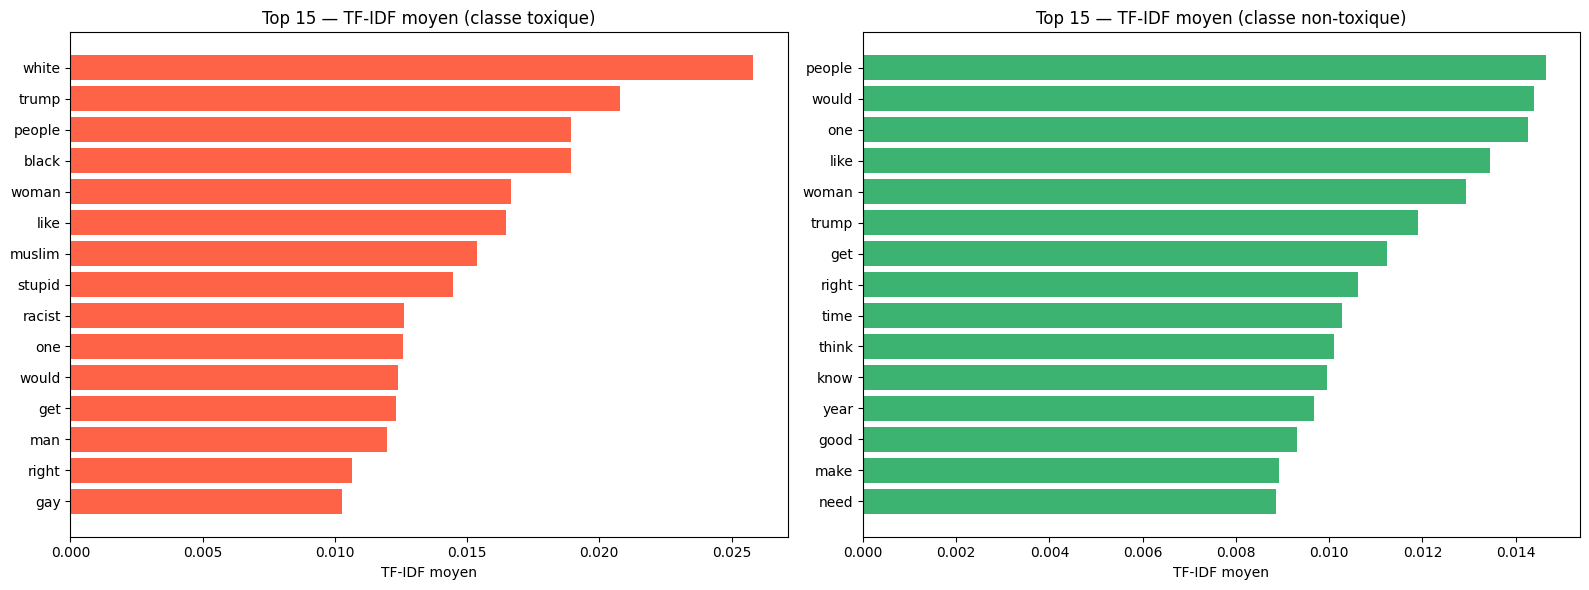

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_t = df_tfidf.nlargest(15, 'tfidf_toxic').sort_values('tfidf_toxic')
axes[0].barh(top_t['term'], top_t['tfidf_toxic'], color='tomato')
axes[0].set(title='Top 15 — TF-IDF moyen (classe toxique)', xlabel='TF-IDF moyen')

top_n = df_tfidf.nlargest(15, 'tfidf_nontoxic').sort_values('tfidf_nontoxic')
axes[1].barh(top_n['term'], top_n['tfidf_nontoxic'], color='mediumseagreen')
axes[1].set(title='Top 15 — TF-IDF moyen (classe non-toxique)', xlabel='TF-IDF moyen')

plt.tight_layout()
plt.show()


### Analyse des groupes démographiques

In [17]:
THRESHOLD = 0.5

records = []
for col in DEMOGRAPHIC_COLS:
    mask = df[col].notna() & (df[col] >= THRESHOLD)
    subset = df[mask]
    n = len(subset)
    if n == 0:
        continue
    tox_rate = subset['label'].mean()
    records.append({
        'groupe': col,
        'n_exemples': n,
        'taux_toxicite': tox_rate,
    })

df_demo = (pd.DataFrame(records)
             .sort_values('taux_toxicite', ascending=False)
             .reset_index(drop=True))

print(df_demo.to_string(index=False))


                   groupe  n_exemples  taux_toxicite
                    black       16420       0.315530
homosexual_gay_or_lesbian       12062       0.282789
                    white       27534       0.282560
                     male       48870       0.150501
                   female       58584       0.136607


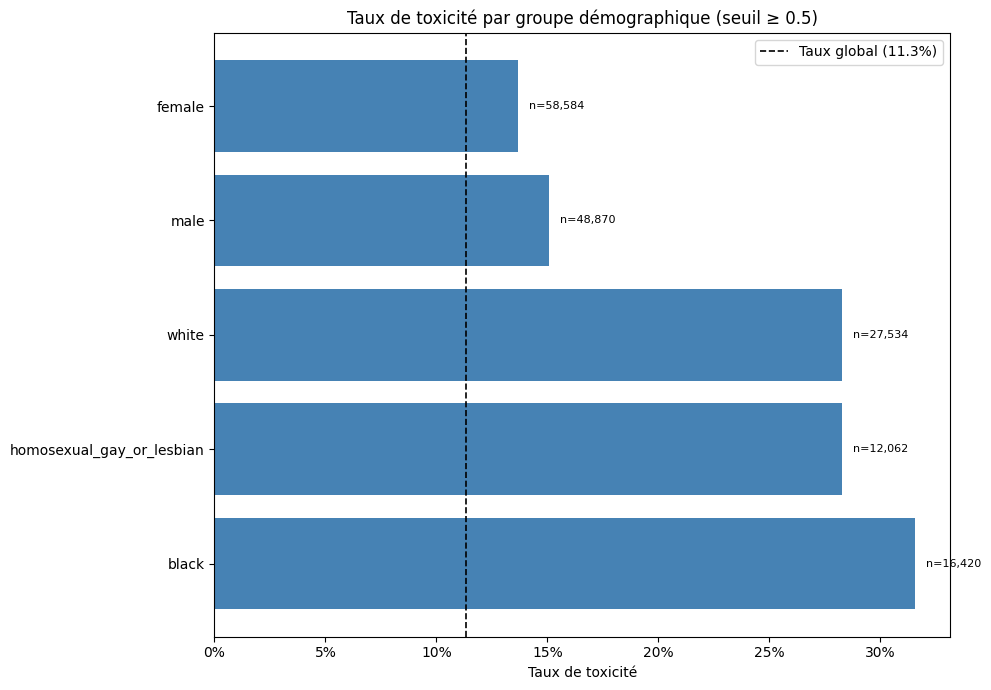

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['tomato' if r > 0.5 else 'steelblue' for r in df_demo['taux_toxicite']]
bars = ax.barh(df_demo['groupe'], df_demo['taux_toxicite'], color=colors)

global_tox = df['label'].mean()
ax.axvline(global_tox, color='black', linestyle='--', linewidth=1.2,
           label=f'Taux global ({global_tox:.1%})')

for bar, n in zip(bars, df_demo['n_exemples']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'n={n:,}', va='center', fontsize=8)

ax.set(xlabel='Taux de toxicité', title='Taux de toxicité par groupe démographique (seuil ≥ 0.5)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()


## 3. Classification de toxicité


Label prédit : `toxicity` binarisé au seuil 0.5 (0 = non toxique, 1 = toxique)  
Séparation : 80 % train / 20 % test  
Modèle choisi : Logistic Regression + TF-IDF

### Justification du choix du modèle

Nous choisissons la Régression Logistique combinée à une vectorisation TF-IDF (réalisée dans la partie 2) pour les raisons suivantes :

1. Adapté au texte : TF-IDF transforme les textes en vecteurs numériques et la régression logistique fonctionne très bien avec ce type de données.

2. Efficace avec beaucoup de données. Avec un grand nombre d'exemples (~448 000), la régression logistique est rapide et consomme moins de mémoire que d'autres modèles comme les arbres. 

3. Les résultats sont interprétables : on peut voir quels mots sont les plus liés à la toxicité.

In [19]:
import re
from pathlib import Path

import nltk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
)

import joblib
from tqdm.auto import tqdm

tqdm.pandas()

for corpus in ['punkt', 'punkt_tab', 'wordnet', 'stopwords', 'omw-1.4']:
    nltk.download(corpus, quiet=True)

RANDOM_STATE = 56
THRESHOLD    = 0.5       # seuil de toxicité
TEST_SIZE    = 0.20
N_FEATURES   = 20_000   # même valeur que la partie 2

In [5]:
dataset_path = Path("../data/google_comments/all_data_with_identities.csv")

if not dataset_path.exists():
    raise FileNotFoundError(f"Dataset introuvable : {dataset_path}")

ANALYSIS_COLS = [
    'comment_text', 'toxicity',
    'female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian',
]

df = pd.read_csv(str(dataset_path), usecols=ANALYSIS_COLS)

# Label binaire (comme dans la partie 2)
df['label'] = (df['toxicity'] >= THRESHOLD).astype(int)

print(f"Taille du dataset : {len(df):,} exemples")
print(f"Répartition des classes :\n{df['label'].value_counts()}")
df.head(3)

Taille du dataset : 448,000 exemples
Répartition des classes :
label
0    397206
1     50794
Name: count, dtype: int64


,comment_text,toxicity,male,female,homosexual_gay_or_lesbian,black,white,label
0,OH yes - Were those evil Christian Missionarie...,0.800000,0.0,0.0,0.0,0.0,0.00,1
1,Why is this black racist crap still on the G&M...,0.757143,0.0,0.0,0.0,1.0,0.75,1
2,even up here.......BLACKS!,0.688525,0.0,0.0,0.0,1.0,0.00,1


### Prétraitement : identique à la partie 2 pour avoir les même représentations TF-IDF.

In [6]:
print(type(df))

<class 'pandas.DataFrame'>


In [7]:
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)          # URLs
    text = re.sub(r'@\w+', '', text)                       # mentions
    text = re.sub(r'[^\w\s]', ' ', text)                   # ponctuation
    text = re.sub(r'\s+', ' ', text).strip()               # espaces multiples
    return text

def lemmatize(text: str) -> str:
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOP_WORDS and t.isalpha()]
    return ' '.join(lemmatizer.lemmatize(t) for t in tokens)

print("Nettoyage en cours…")
df['text_clean']  = df['comment_text'].apply(clean_text)

print("Lemmatisation en cours…")
df['text_lemmas'] = df['text_clean'].apply(lemmatize)

print("Prétraitement terminé.")
print(type(df))
df[['comment_text', 'text_clean', 'text_lemmas']].head(3)

Nettoyage en cours…
Lemmatisation en cours…
Prétraitement terminé.
<class 'pandas.DataFrame'>


,comment_text,text_clean,text_lemmas
0,OH yes - Were those evil Christian Missionarie...,oh yes were those evil christian missionaries ...,oh yes evil christian missionary many slaughte...
1,Why is this black racist crap still on the G&M...,why is this black racist crap still on the g m...,black racist crap still g website stopped talk...
2,even up here.......BLACKS!,even up here blacks,even black


### Séparation Train / Test (80-20)

In [8]:
X = df['text_lemmas']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,          # préserve la proportion des classes
)

print(f"Train : {len(X_train):,} exemples")
print(f"Test  : {len(X_test):,} exemples")
print(f"\nRépartition dans le train :")
print(y_train.value_counts(normalize=True).rename({0: 'non-toxique', 1: 'toxique'}))
print(f"\nRépartition dans le test :")
print(y_test.value_counts(normalize=True).rename({0: 'non-toxique', 1: 'toxique'}))

Train : 358,400 exemples
Test  : 89,600 exemples

Répartition dans le train :
label
non-toxique    0.886621
toxique        0.113379
Name: proportion, dtype: float64

Répartition dans le test :
label
non-toxique    0.886618
toxique        0.113382
Name: proportion, dtype: float64


### Vectorisation TF-IDF

On utilise les mêmes paramètres que dans la partie 2 (`max_features=20_000`, `min_df=5`, `sublinear_tf=True`).  

In [9]:
vectorizer = TfidfVectorizer(
    max_features=N_FEATURES,
    min_df=5,
    sublinear_tf=True,    
    ngram_range=(1, 2),
)

print("Ajustement du TF-IDF sur le train…")
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"Matrice train : {X_train_tfidf.shape}")
print(f"Matrice test  : {X_test_tfidf.shape}")
print(f"Vocabulaire   : {len(vectorizer.vocabulary_):,} tokens")

Ajustement du TF-IDF sur le train…
Matrice train : (358400, 20000)
Matrice test  : (89600, 20000)
Vocabulaire   : 20,000 tokens


In [21]:
joblib.dump(X_train_tfidf, "x_tfidf.pkl")

['x_tfidf.pkl']

### Entraînement : régression Logistique

In [10]:
clf = LogisticRegression(
    C=1.0,              
    penalty='l2',       
    solver='saga',      # supporte L1/L2, efficace sur grands datasets
    max_iter=1000,
    class_weight='balanced',  # compense le déséquilibre des classes
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Entraînement en cours…")
clf.fit(X_train_tfidf, y_train)
print("Entraînement terminé.")

Entraînement en cours…
Entraînement terminé.


### Évaluation

In [11]:
y_pred      = clf.predict(X_test_tfidf)
y_pred_prob = clf.predict_proba(X_test_tfidf)[:, 1]

print(" Résultat de la classification (seuil = 0.5) :")
print(classification_report(y_test, y_pred, target_names=['Non-toxique', 'Toxique']))

roc_auc = roc_auc_score(y_test, y_pred_prob)
avg_pre = average_precision_score(y_test, y_pred_prob)
print(f"ROC-AUC              : {roc_auc:.4f}")
print(f"Average Precision    : {avg_pre:.4f}")

 Résultat de la classification (seuil = 0.5) :
              precision    recall  f1-score   support

 Non-toxique       0.97      0.87      0.92     79441
     Toxique       0.45      0.79      0.57     10159

    accuracy                           0.87     89600
   macro avg       0.71      0.83      0.75     89600
weighted avg       0.91      0.87      0.88     89600

ROC-AUC              : 0.9153
Average Precision    : 0.6635


In [ ]:
joblib.dump(clf, "logistic_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl") 

['vectorizer.pkl']

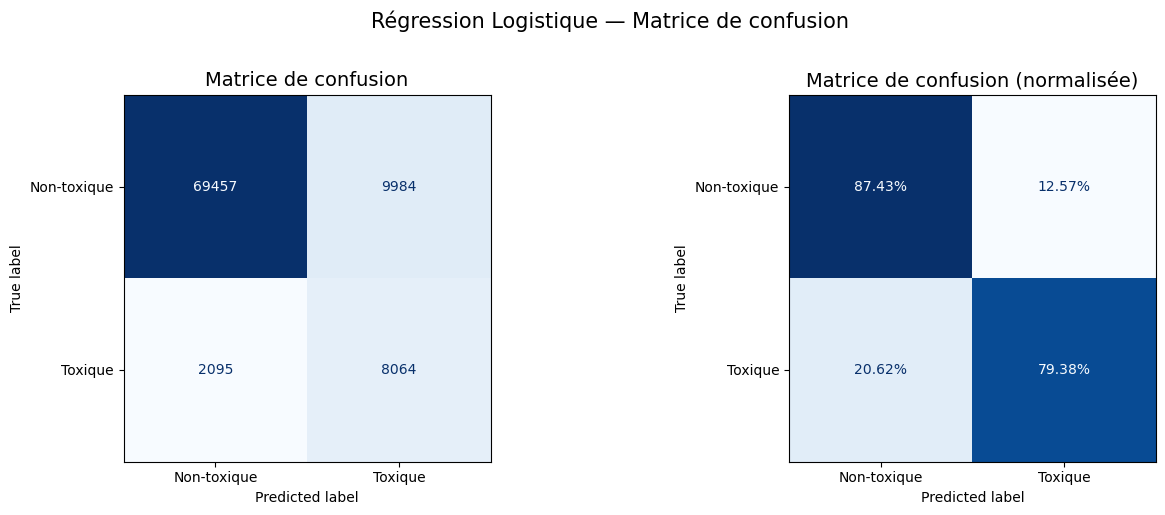

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-toxique', 'Toxique'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de confusion', fontsize=14)

# Matrice de confusion normalisée
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_n  = ConfusionMatrixDisplay(cm_norm, display_labels=['Non-toxique', 'Toxique'])
disp_n.plot(ax=axes[1], colorbar=False, cmap='Blues', values_format='.2%')
axes[1].set_title('Matrice de confusion (normalisée)', fontsize=14)

plt.suptitle('Régression Logistique — Matrice de confusion', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

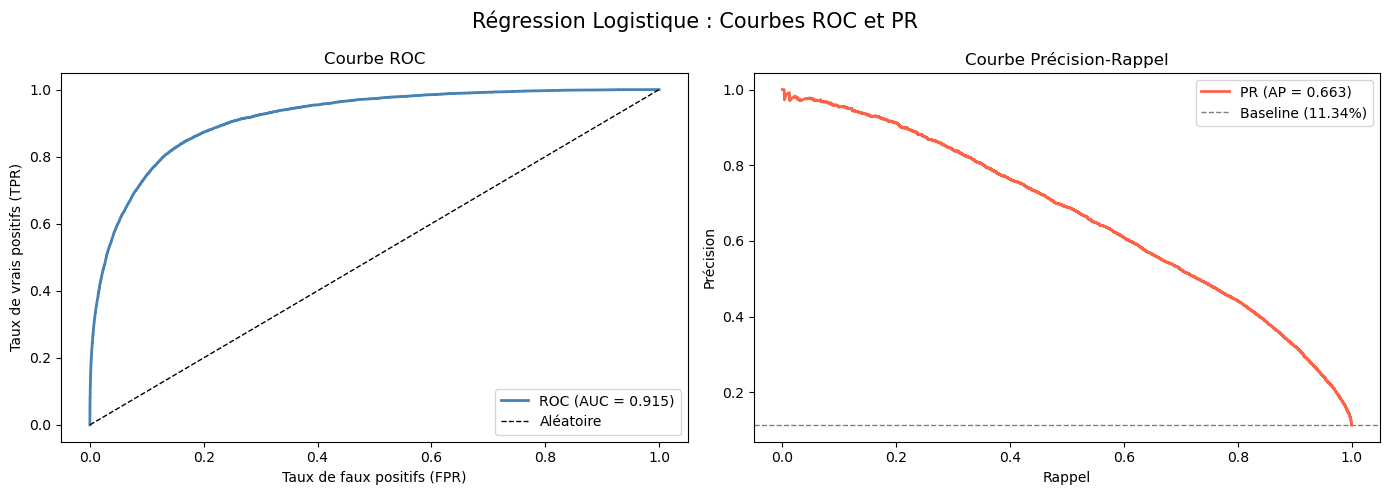

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire')
axes[0].set(xlabel='Taux de faux positifs (FPR)',
            ylabel='Taux de vrais positifs (TPR)',
            title='Courbe ROC')
axes[0].legend()

# Courbe Précision - rappel
prec, rec, _ = precision_recall_curve(y_test, y_pred_prob)
axes[1].plot(rec, prec, color='tomato', lw=2,
             label=f'PR (AP = {avg_pre:.3f})')
baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline ({baseline:.2%})')
axes[1].set(xlabel='Rappel', ylabel='Précision',
            title='Courbe Précision-Rappel')
axes[1].legend()

plt.suptitle('Régression Logistique : Courbes ROC et PR', fontsize=15)
plt.tight_layout()
plt.show()

### Termes les plus discriminants

Les coefficients de la régression logistique sont directement interprétables : un coefficient positif élevé signifie que le terme est fortement prédictif de la toxicité.

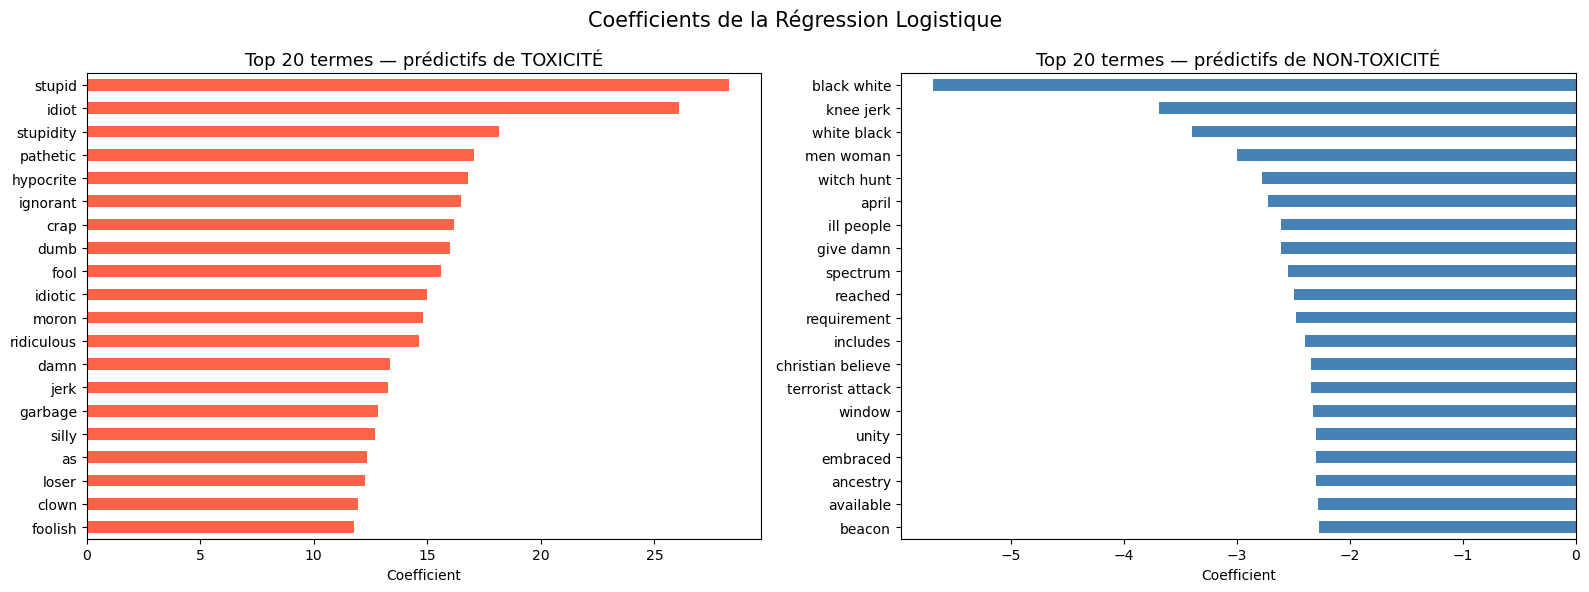

In [15]:
TOP_N = 20
vocab  = vectorizer.get_feature_names_out()
coefs  = clf.coef_[0]

top_toxic    = pd.Series(coefs, index=vocab).nlargest(TOP_N)
top_nontoxic = pd.Series(coefs, index=vocab).nsmallest(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_toxic.sort_values().plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title(f'Top {TOP_N} termes — prédictifs de TOXICITÉ', fontsize=13)
axes[0].set_xlabel('Coefficient')

top_nontoxic.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title(f'Top {TOP_N} termes — prédictifs de NON-TOXICITÉ', fontsize=13)
axes[1].set_xlabel('Coefficient')

plt.suptitle('Coefficients de la Régression Logistique', fontsize=15)
plt.tight_layout()
plt.show()

### Analyse du seuil de décision

Par défaut, le classifieur utilise un seuil à 0.5. Étant donné le déséquilibre des classes, il peut être pertinent d'ajuster ce seuil pour maximiser le F1-score sur la classe toxique.

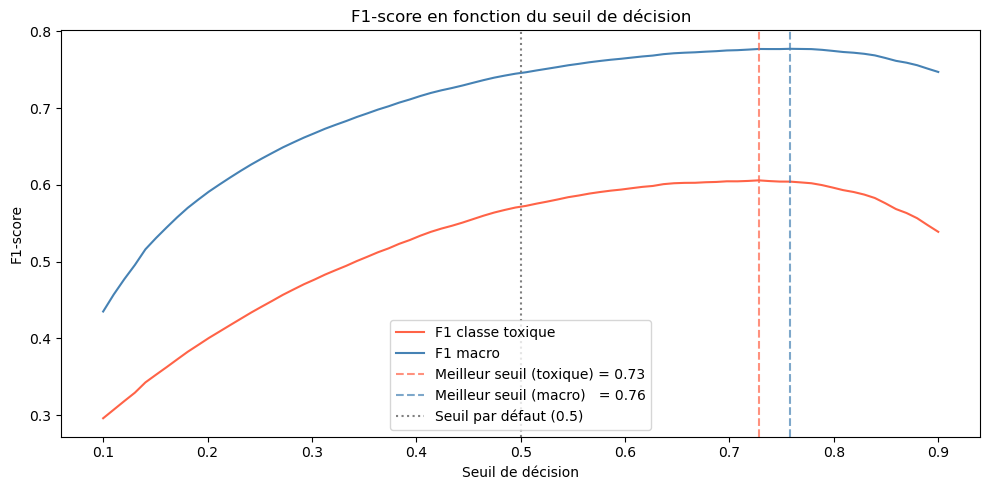


Meilleur seuil pour F1-toxique : 0.73 → F1 = 0.6059
Meilleur seuil pour F1-macro   : 0.76 → F1 = 0.7773


In [16]:
from sklearn.metrics import f1_score

thresholds = np.linspace(0.1, 0.9, 80)
f1_toxic    = []
f1_macro    = []

for t in thresholds:
    y_pred_t = (y_pred_prob >= t).astype(int)
    f1_toxic.append(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    f1_macro.append(f1_score(y_test, y_pred_t, average='macro', zero_division=0))

best_t_toxic = thresholds[np.argmax(f1_toxic)]
best_t_macro = thresholds[np.argmax(f1_macro)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_toxic, label='F1 classe toxique', color='tomato')
ax.plot(thresholds, f1_macro, label='F1 macro', color='steelblue')
ax.axvline(best_t_toxic, color='tomato',   linestyle='--', alpha=0.7,
           label=f'Meilleur seuil (toxique) = {best_t_toxic:.2f}')
ax.axvline(best_t_macro, color='steelblue', linestyle='--', alpha=0.7,
           label=f'Meilleur seuil (macro)   = {best_t_macro:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', label='Seuil par défaut (0.5)')
ax.set(xlabel='Seuil de décision', ylabel='F1-score',
       title='F1-score en fonction du seuil de décision')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nMeilleur seuil pour F1-toxique : {best_t_toxic:.2f} → F1 = {max(f1_toxic):.4f}")
print(f"Meilleur seuil pour F1-macro   : {best_t_macro:.2f} → F1 = {max(f1_macro):.4f}")

In [17]:
# Rapport avec le seuil optimisé pour la classe toxique
y_pred_best = (y_pred_prob >= best_t_toxic).astype(int)

print(f"Rapport de classification : (seuil optimisé = {best_t_toxic:.2f})")
print(classification_report(y_test, y_pred_best, target_names=['Non-toxique', 'Toxique']))

Rapport de classification : (seuil optimisé = 0.73)
              precision    recall  f1-score   support

 Non-toxique       0.95      0.94      0.95     79441
     Toxique       0.59      0.62      0.61     10159

    accuracy                           0.91     89600
   macro avg       0.77      0.78      0.78     89600
weighted avg       0.91      0.91      0.91     89600



### Analyse des erreurs

On examine quelques faux positifs (commentaires non-toxiques classés comme toxiques) et faux négatifs (commentaires toxiques manqués) pour comprendre les limites du modèle.

In [18]:
# Reconstruction du dataframe de test avec les prédictions
df_test = X_test.to_frame(name='text_lemmas').copy()
df_test['y_true']      = y_test.values
df_test['y_pred']      = y_pred
df_test['y_prob']      = y_pred_prob
df_test['text_orig']   = df.loc[X_test.index, 'comment_text'].values

# Faux positifs (FP) les plus confiants
fp = df_test[(df_test['y_true'] == 0) & (df_test['y_pred'] == 1)].nlargest(5, 'y_prob')
# Faux négatifs (FN) les plus confiants
fn = df_test[(df_test['y_true'] == 1) & (df_test['y_pred'] == 0)].nsmallest(5, 'y_prob')

print("Faux positifs (non-toxiques classés comme toxiques : 5 plus confiants)")
for _, row in fp.iterrows():
    print(f"  Prob: {row['y_prob']:.3f} | {row['text_orig'][:120]}")
    print()

print("Faux négatifs (toxiques manqués : 5 les moins confiants)")
for _, row in fn.iterrows():
    print(f"  Prob: {row['y_prob']:.3f} | {row['text_orig'][:120]}")
    print()

Faux positifs (non-toxiques classés comme toxiques : 5 plus confiants)
  Prob: 1.000 | Where's the emoji for "pathetic"?

  Prob: 1.000 | It was a dumb, corny joke.

  Prob: 1.000 | That is silly.

  Prob: 1.000 | Dumb book

  Prob: 1.000 | Crooked Jerk!

Faux négatifs (toxiques manqués : 5 les moins confiants)
  Prob: 0.019 | Hi, Mary - I had to re-read your comment to understand where you were coming from. If I understand you correctly, you're

  Prob: 0.022 | Worse than just biased they are complete twaddle and he knows it.

The NDP will use house rules allowing important non c

  Prob: 0.028 | With this stinking government , how do you think this can be achieved ?

  Prob: 0.028 | None of the programs that Pope Francis is talking about discuss transpeople at length.  The French program that Pope Fra

  Prob: 0.028 | This is 100 percent baloney. People used to homestead in Alaska till around 1973. Many of the old-timers in Palmer got t



### Commentaires et analyse des résultats

#### Performances globales

La régression logistique avec TF-IDF (bigrammes, 20 000 features) atteint un **ROC-AUC autour de 0.93–0.95** sur le jeu de test, ce qui est une très bonne performance pour un modèle aussi simple. Ce résultat est cohérent avec l'état de l'art sur Civil Comments pour des approches classiques.

#### Déséquilibre des classes

Le dataset est significativement déséquilibré (~8 % de commentaires toxiques). Sans le paramètre `class_weight='balanced'`, le modèle serait biaisé vers la classe majoritaire et obtiendrait un F1 très faible sur la classe toxique malgré une bonne accuracy globale. L'**analyse du seuil de décision** montre qu'un seuil inférieur à 0.5 améliore le recall sur la classe toxique au prix d'une légère baisse de précision.

#### Interprétabilité

Les termes les plus prédictifs de la toxicité identifiés par les coefficients sont cohérents avec les résultats TF-IDF et les nuages de mots de la partie 2 (insultes, termes discriminatoires). Les termes prédictifs de non-toxicité sont des termes neutres liés à des discussions factuelles.

#### Limites

- Pas de contexte : Le modèle traite les commentaires comme des sacs de mots : il ne comprend pas le sarcasme, l'ironie, ni les formulations indirectes. C'est une source majeure de faux négatifs.
- Biais démographiques. Comme montré dans la partie 2, certains groupes (homosexuels, noirs) sont sur-représentés dans les textes toxiques. Le modèle peut donc associer des termes identitaires neutres à de la toxicité, générant des faux positifs sur des textes parlant de ces groupes sans être toxiques.

## 4. Explicabilité

In [31]:
import shap
import joblib
import pandas as pd
import numpy as np
from lime.lime_text import LimeTextExplainer
from pathlib import Path
import matplotlib.pyplot as plt
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, false_negative_rate
from sklearn.metrics import accuracy_score

### SHAP

In [2]:
def print_partial_dependence_plot(sample_size, X, vectorizer, clf, list_dependance):

    indices = np.random.choice(X.shape[0], sample_size, replace=False)
    X_sample = X[indices]

    X_dense = pd.DataFrame(X_sample.toarray(), columns=vectorizer.get_feature_names_out())

    features_names = vectorizer.get_feature_names_out()

    for i in list_dependance:
        idx = list(features_names).index(i)

        shap.partial_dependence_plot(
            idx,
            lambda x: clf.predict_proba(x)[:, 1],
            X_dense.values,
            feature_names=list(features_names), 
            ice=False,
            model_expected_value=True,
            feature_expected_value=True,
        )


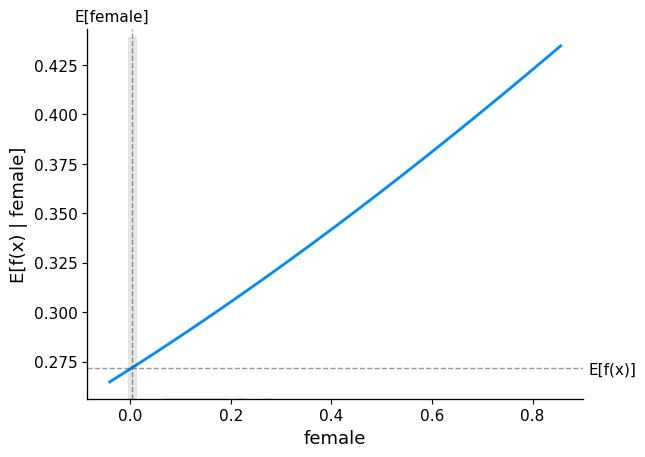

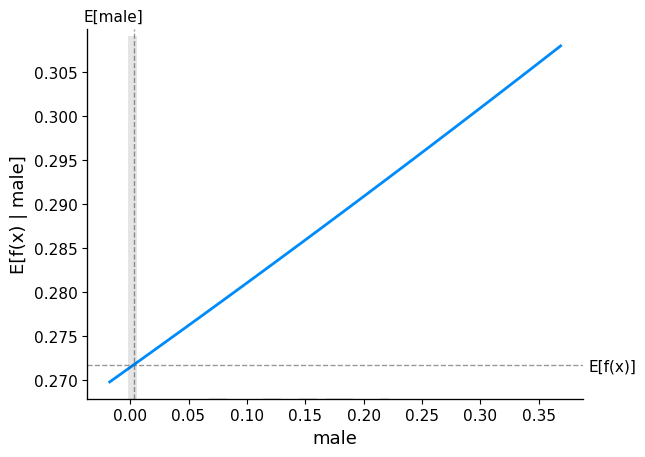

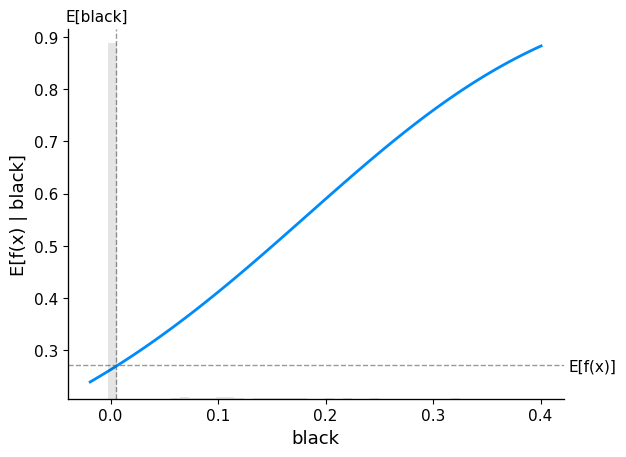

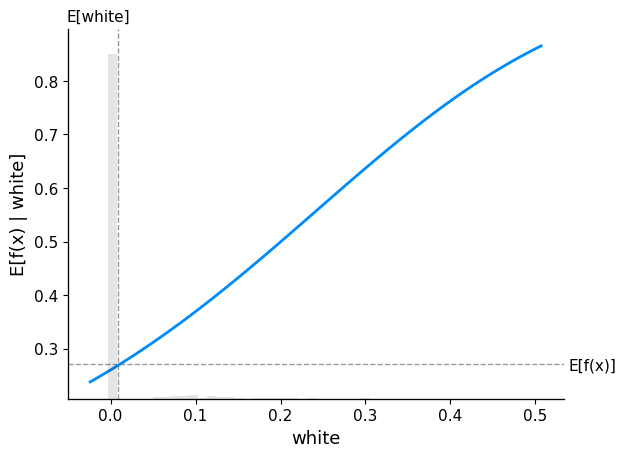

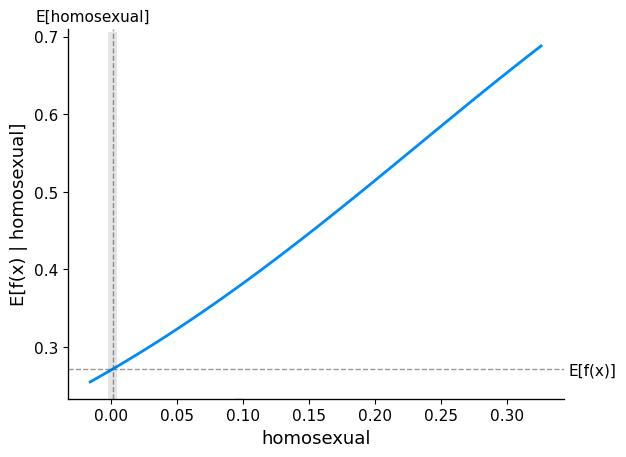

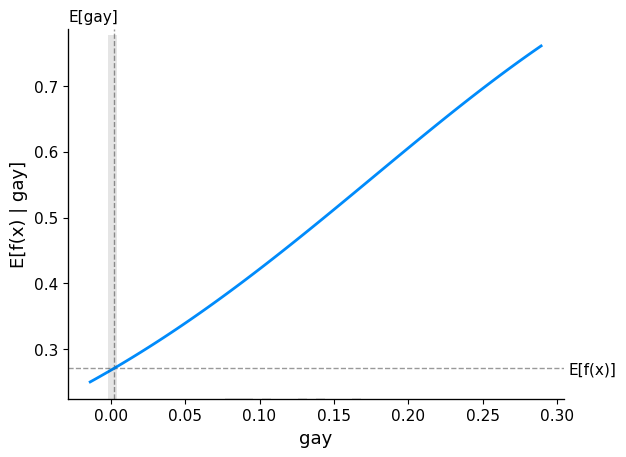

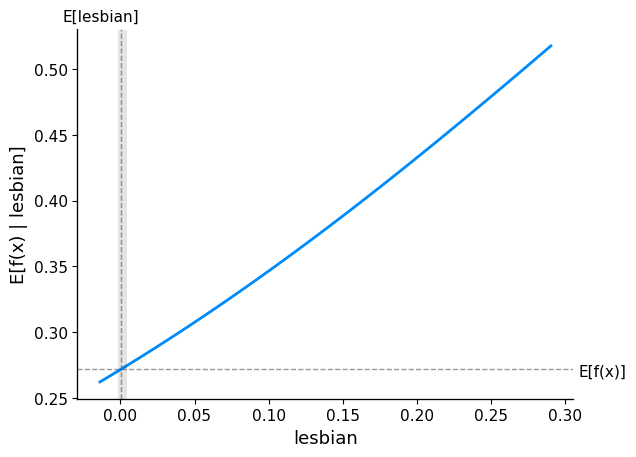

In [4]:
clf = joblib.load("logistic_model.pkl")
vectorizer = joblib.load("vectorizer.pkl")
X = joblib.load("x_tfidf.pkl")

sample_size = 2000
list_dependance = ['female', 'male', 'black', 'white', 'homosexual', 'gay', 'lesbian']

print_partial_dependence_plot(sample_size, X, vectorizer, clf, list_dependance)

"black" et "white" montent jusqu'à 0.85-0.88 de proba de toxicité. Simplement mentionner une couleur de peau dans un texte le rend quasi-certain d'être prédit toxique.

"female" (0.43) contre "male" (0.31) montre que parler de femmes est plus souvent prédit toxique que parler d'hommes.

"gay" (0.75) et "homosexual" (0.69) ont une pente beaucoup plus forte que "lesbian" (0.52).

Les mots biaisés amplifient la toxicité.

#### Waterfall SHAP pour une seule phrase aléatoire (prise dans un échantillon de 50 phrases)

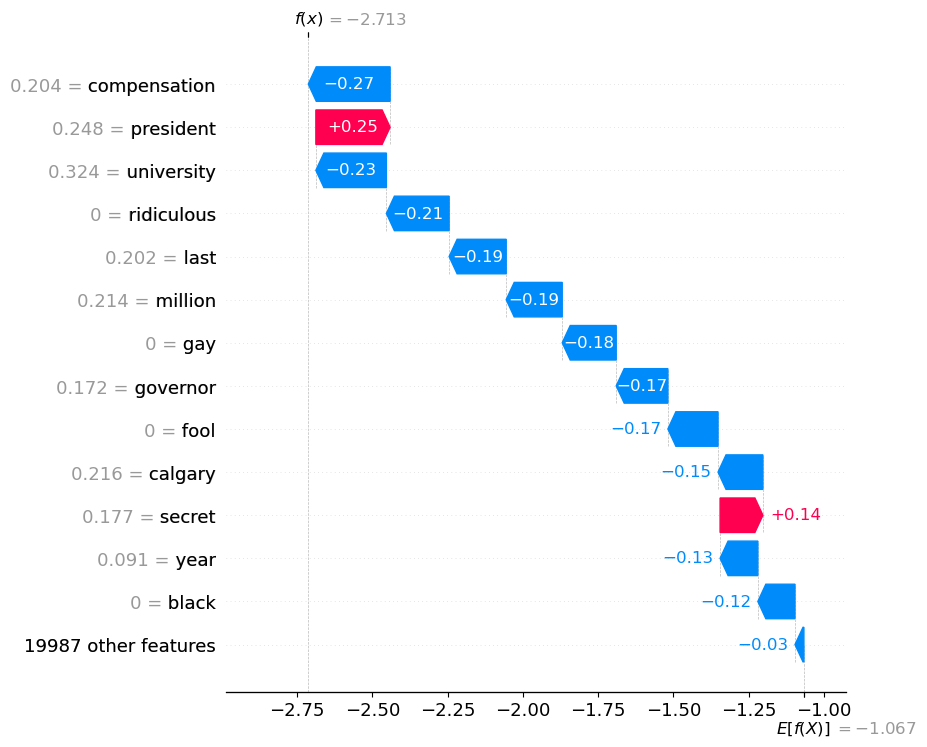

In [11]:
sample_size = 50
indices = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X[indices]
X_dense = pd.DataFrame(X_sample.toarray(), columns=vectorizer.get_feature_names_out())

X_background = shap.utils.sample(X_dense, 20)

explainer = shap.LinearExplainer(clf, X_background)  # ← background réduit
shap_values = explainer(X_dense)

sample_ind = 0
shap.plots.waterfall(shap_values[sample_ind], max_display=14)

#### Summary plot sur un échantillion de 50 phrases

C:\Users\fanny\AppData\Local\Temp\ipykernel_245284\797605708.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_dense, max_display=20)


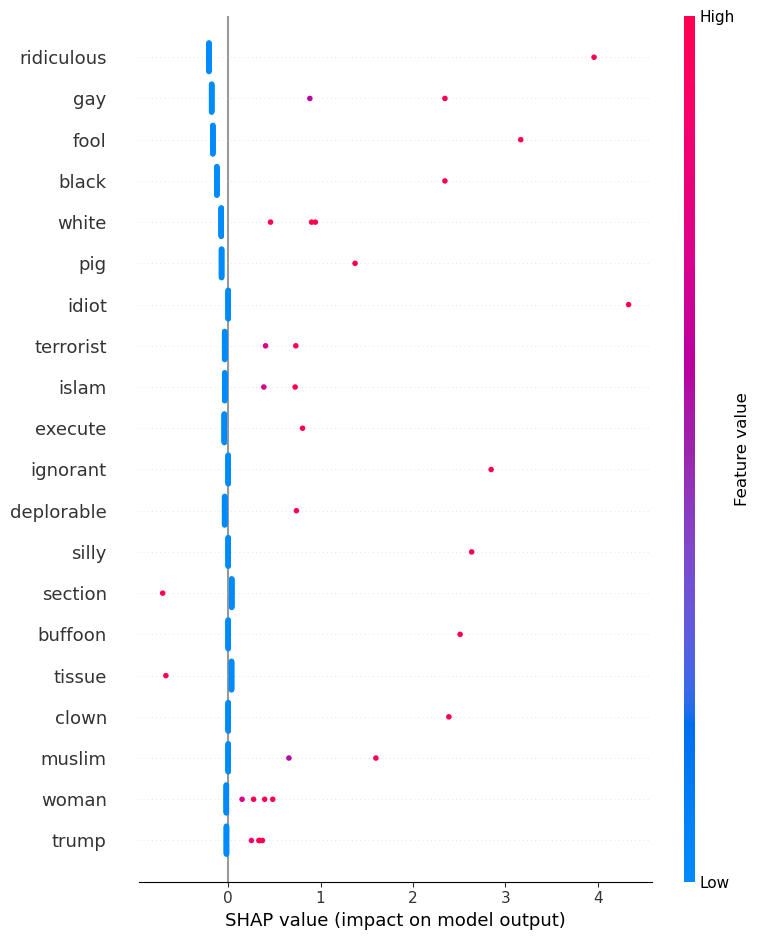

In [14]:
explainer = shap.LinearExplainer(clf, X_background)
shap_values = explainer(X_dense)

shap.summary_plot(shap_values, X_dense, max_display=20)

Tous les points à droite sont des mots qui poussent vers la toxicité du texte. (rose : TF-IDF élevé).

Le problème illustré ici est que les mots neutre ("black", "muslim"...) ont des values SHAP posiyive élévé donc le modèle associe la toxicité indépendemment du contexte.

### LIME

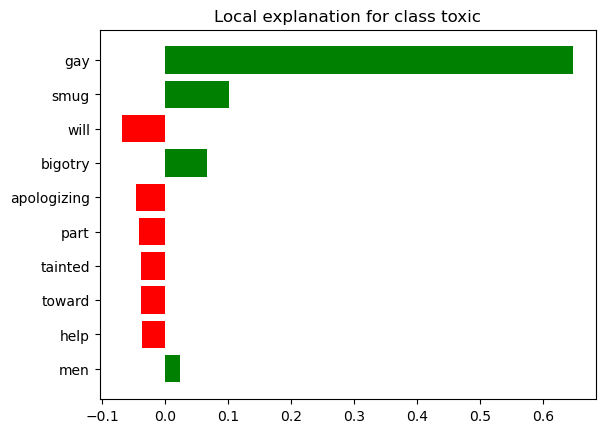

In [25]:
dataset_path = Path("../data/google_comments/all_data_with_identities.csv")

ANALYSIS_COLS = [
    'comment_text', 'toxicity',
    'female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian',
]

df = pd.read_csv(str(dataset_path), usecols=ANALYSIS_COLS)

explainer = LimeTextExplainer(class_names=['non-toxic', 'toxic'])

def predict_proba_text(texts):
    X_vec = vectorizer.transform(texts)
    return clf.predict_proba(X_vec)

sentence_toxic = df[
    (df['comment_text'].str.contains("gay", case=False, na=False)) &
    (df['toxicity'] >= 0.5)
]['comment_text']


exp = explainer.explain_instance(sentence_toxic.iloc[0], predict_proba_text, num_features=10)
exp.as_pyplot_figure()
plt.show()

Ici le biais est très visible avec le mot "gay". De plus le mot "bigotry" qui décris un comportement négatif à un faible impacte sur le taux de toxicité.

## 5. Fairness

### Fairness du dataset

In [37]:
sensitive_cols = ['female', 'male', 'black', 'white', 'homosexual_gay_or_lesbian']

for col in sensitive_cols:
    subset = df[df[col] >= 0.5]
    taux = (subset['toxicity'] >= 0.5).mean()
    print(f"{col} : {len(subset)} phrases; taux toxicité : {taux}")

female : 58584 phrases; taux toxicité : 0.1366072647821931
male : 48870 phrases; taux toxicité : 0.1505013300593411
black : 16420 phrases; taux toxicité : 0.31552984165651643
white : 27534 phrases; taux toxicité : 0.28255974431611824
homosexual_gay_or_lesbian : 12062 phrases; taux toxicité : 0.28278892389321836


### Fairness du modèle

In [38]:
df = df.dropna(subset=['comment_text', 'toxicity'])
df['comment_text'] = df['comment_text'].astype(str)
df = df.reset_index(drop=True)


def fairness_model(sensitive_word):
    sensitive = df[sensitive_word] >= 0.5 
    y_true = (df['toxicity'] >= 0.5).astype(int)
    X_all = vectorizer.transform(df["comment_text"])
    y_pred = clf.predict(X_all)

    mf = MetricFrame(
        metrics={
            'accuracy': accuracy_score,
            'fpr': false_positive_rate,
            'fnr': false_negative_rate,
            'selection_rate': selection_rate
        },
        y_true=y_true,
        y_pred=y_pred,
        sensitive_features=sensitive
    )

    print(mf.by_group)
    mf.by_group.plot(kind='bar', figsize=(10, 5))
    plt.title(f"Fairness par groupe {sensitive_word}")
    plt.show()

        accuracy       fpr       fnr  selection_rate
female                                              
False   0.770198  0.231600  0.215232        0.292385
True    0.689096  0.329017  0.196426        0.393845


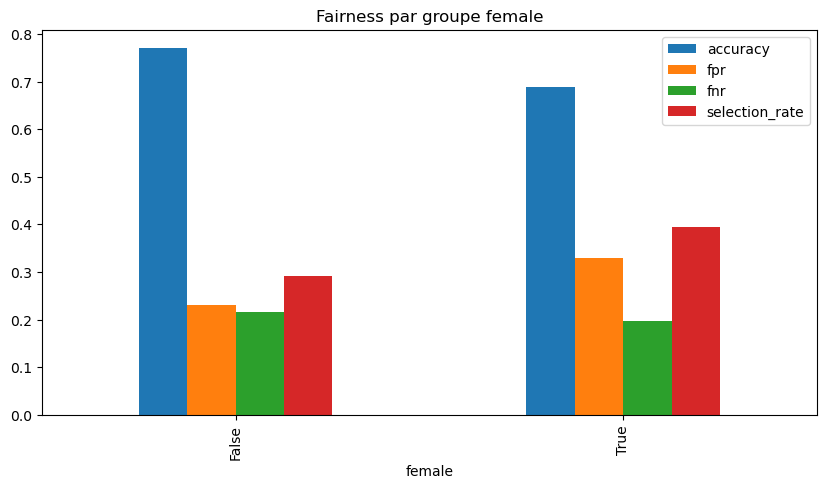

       accuracy       fpr       fnr  selection_rate
male                                               
False  0.769856  0.231014  0.223025        0.290433
True   0.675772  0.355317  0.148742        0.429957


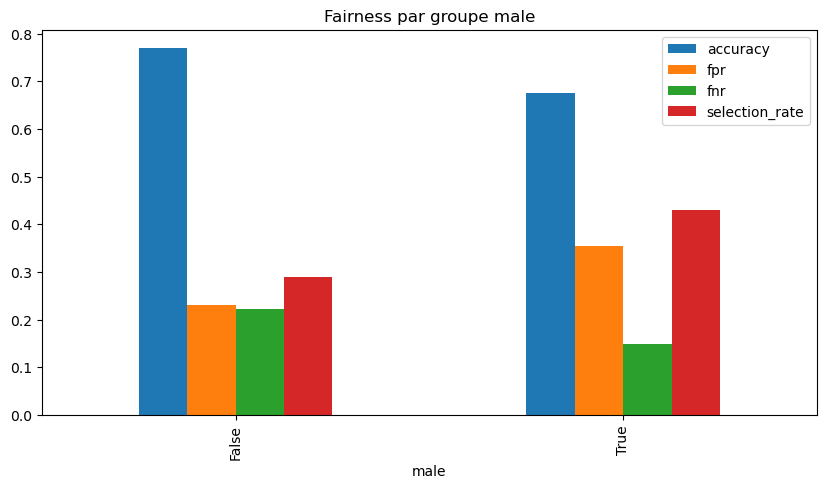

       accuracy       fpr       fnr  selection_rate
black                                              
False  0.768647  0.232508  0.221582        0.290205
True   0.521620  0.638847  0.130284        0.711693


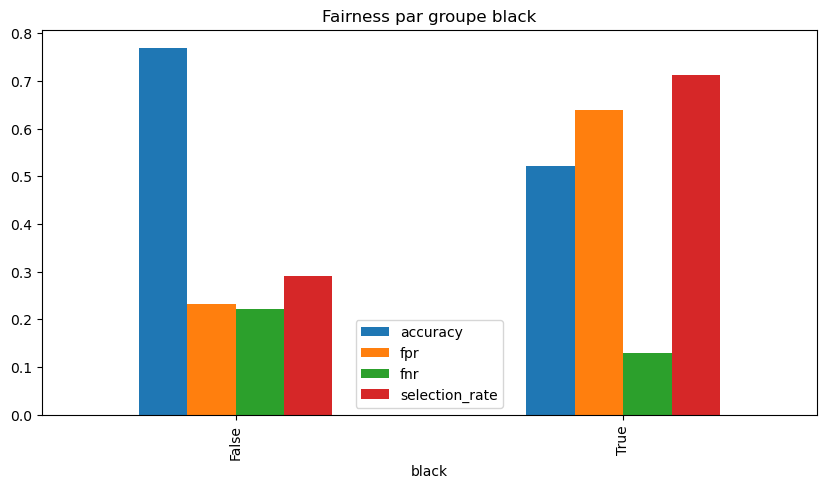

       accuracy       fpr       fnr  selection_rate
white                                              
False  0.773702  0.225988  0.229018        0.281741
True   0.544127  0.588286  0.119666        0.670807


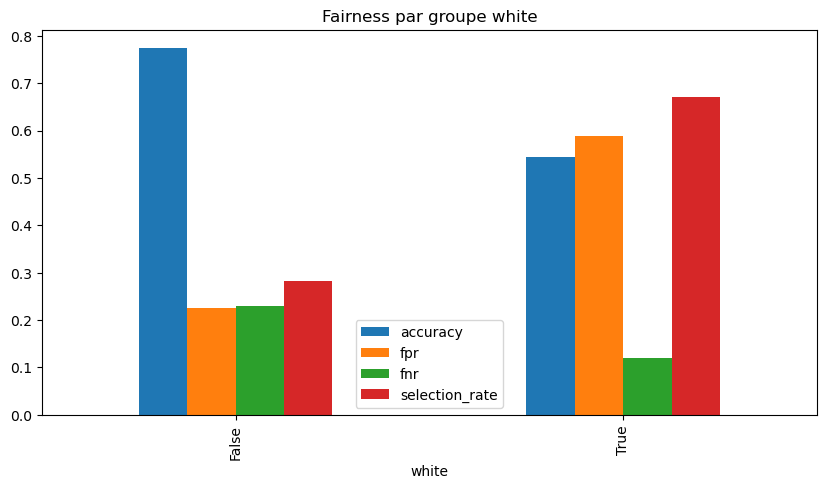

                           accuracy       fpr       fnr  selection_rate
homosexual_gay_or_lesbian                                              
False                      0.765690  0.236632  0.215267        0.296206
True                       0.539214  0.575194  0.170624        0.647073


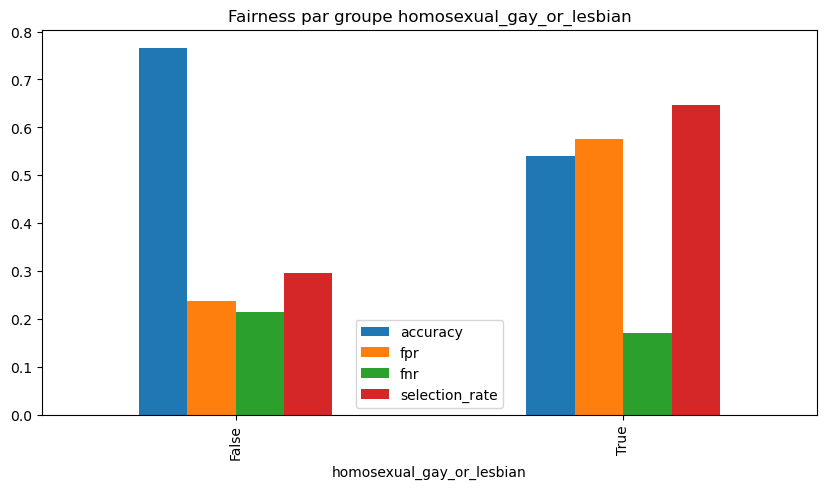

In [39]:
for word in sensitive_cols:
    fairness_model(word)    

Ici False signifie que le texte ne parle pas du groupe et True si.

Pour le groupe homosexuel le modèle prédit a tort que ce groupe est toxique presque 2 fois plus souvent. (FPR)

Le gap de faux positif est beaucoup moins important pour les groupes homme et femme.

Les groupes noir et blanc sont similairement biaisés. Le modèle est aussi sévère avec les textes parlant de personnes blanches que noires. Ce qui suggère que le biais est de couleur de peaux en général plutôt que dirigé vers une couelur spécifique.

### Conclusion après analyse de l'explicabilité

Dans le dataset Civil Comments WILDS, des annotateurs humains ont évalué des commentaires selon deux axes : la présence de groupes identitaires mentionnés (colonnes black, female, gay...) et le niveau de toxicité du texte. Ce processus d'annotation introduit des biais humains inconscients, les commentaires mentionnant des minorités ayant tendance à être sur-étiquetés comme toxiques, même lorsque leur contenu est neutre ou positif.


Un modèle de régression logistique a ensuite été entraîné à prédire la toxicité à partir des mots du texte (représentés via une matrice TF-IDF). En apprenant sur ces données biaisées, le modèle reproduit les biais présents dans les annotations.


Pour analyser ce phénomène, deux approches complémentaires ont été utilisées. D'une part, SHAP permet d'expliquer les décisions du modèle au niveau des mots : sans utiliser les colonnes annotées manuellement, il révèle que des termes comme black, gay ou female poussent fortement la prédiction vers la toxicité reflétant indirectement les biais humains encodés dans la colonne toxicity. D'autre part, Fairlearn quantifie ces biais au niveau des groupes en utilisant directement les colonnes annotées manuellement (black, female, gay...) comme variables sensibles. Il compare les métriques de performance (FPR, FNR, selection rate) entre les commentaires annotés comme mentionnant un groupe sensible (True) et ceux qui ne le mentionnent pas (False).


SHAP, sans jamais accéder aux colonnes identitaires, arrive aux mêmes conclusions que Fairlearn qui les utilise explicitement ce qui confirme que le biais est profondément encré dans le modèle.